<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [5]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data

df = pd.read_csv("survey_data.csv")

# Display the first few rows to understand the structure of the data
df.head()


'wget' is not recognized as an internal or external command,
operable program or batch file.


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



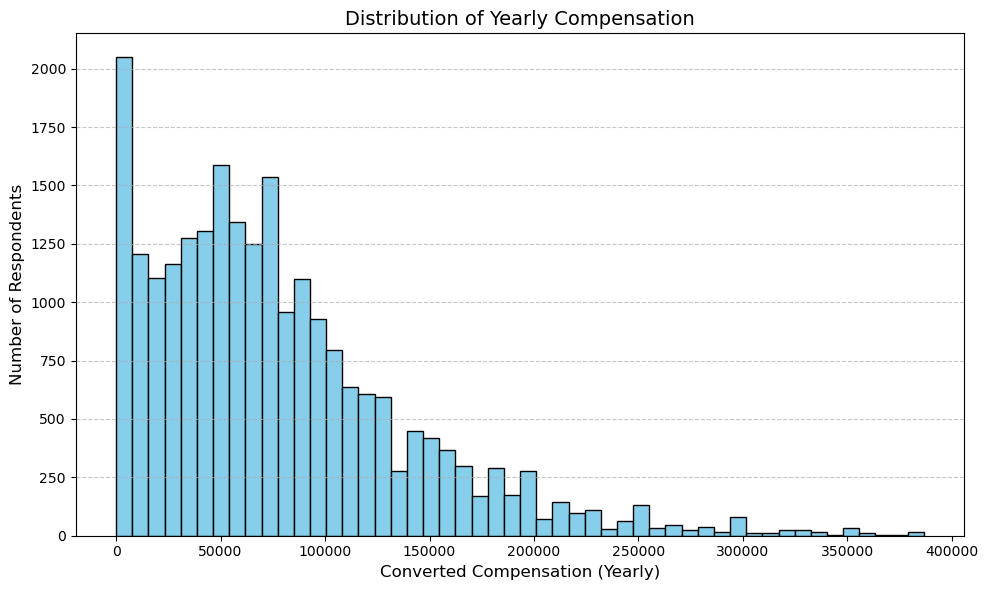

In [7]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# Select the relevant column and drop missing values
comp_data = df['ConvertedCompYearly'].dropna()

# Optional: remove extreme outliers for better visualization
comp_data_filtered = comp_data[comp_data < comp_data.quantile(0.99)]  # keep 99% of data

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(comp_data_filtered, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Yearly Compensation', fontsize=14)
plt.xlabel('Converted Compensation (Yearly)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



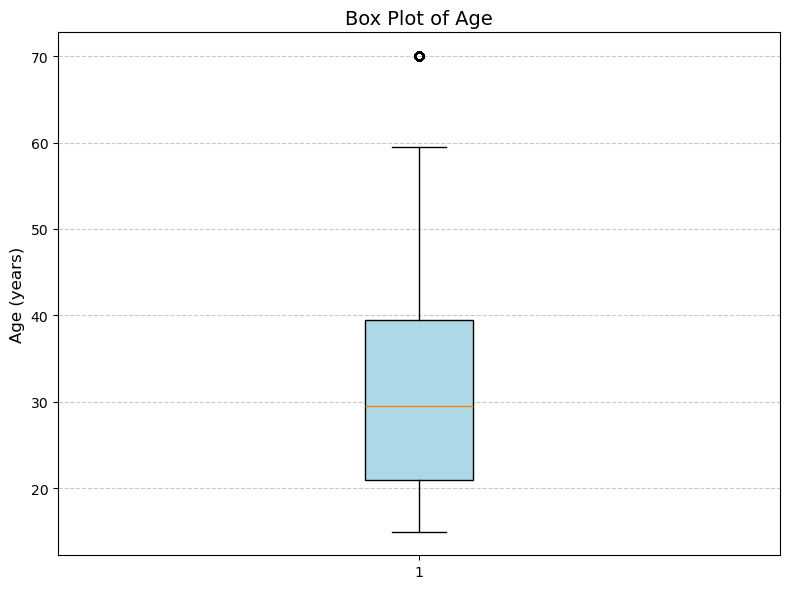

In [9]:
## Write your code here


# Map age categories to numeric midpoints
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

# Create a numeric Age column
df['Age_numeric'] = df['Age'].map(age_mapping)

# Drop missing values
age_data = df['Age_numeric'].dropna()

# Plot box plot
plt.figure(figsize=(8,6))
plt.boxplot(age_data, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Age', fontsize=14)
plt.ylabel('Age (years)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



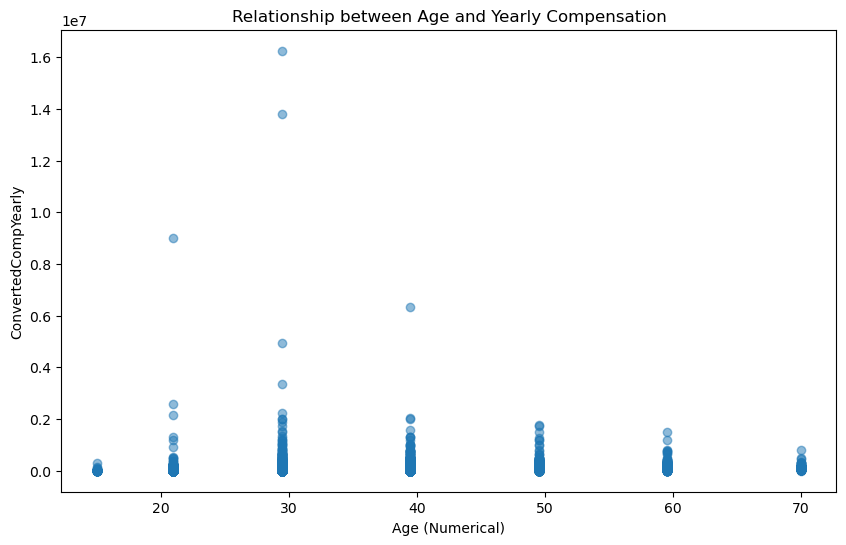

In [16]:
## Write your code here

df_scatter = df.dropna(subset=['Age_numeric', 'ConvertedCompYearly']).copy()

# Create scatter plot: Generate a scatter plot with Age_numerical on the x-axis and ConvertedCompYearly on the y-axis.
plt.figure(figsize=(10, 6))
plt.scatter(df_scatter['Age_numeric'], df_scatter['ConvertedCompYearly'], alpha=0.5)

# Add labels and title: Add appropriate labels to the axes and a title to the plot.
plt.title('Relationship between Age and Yearly Compensation')
plt.xlabel('Age (Numerical)')
plt.ylabel('ConvertedCompYearly')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


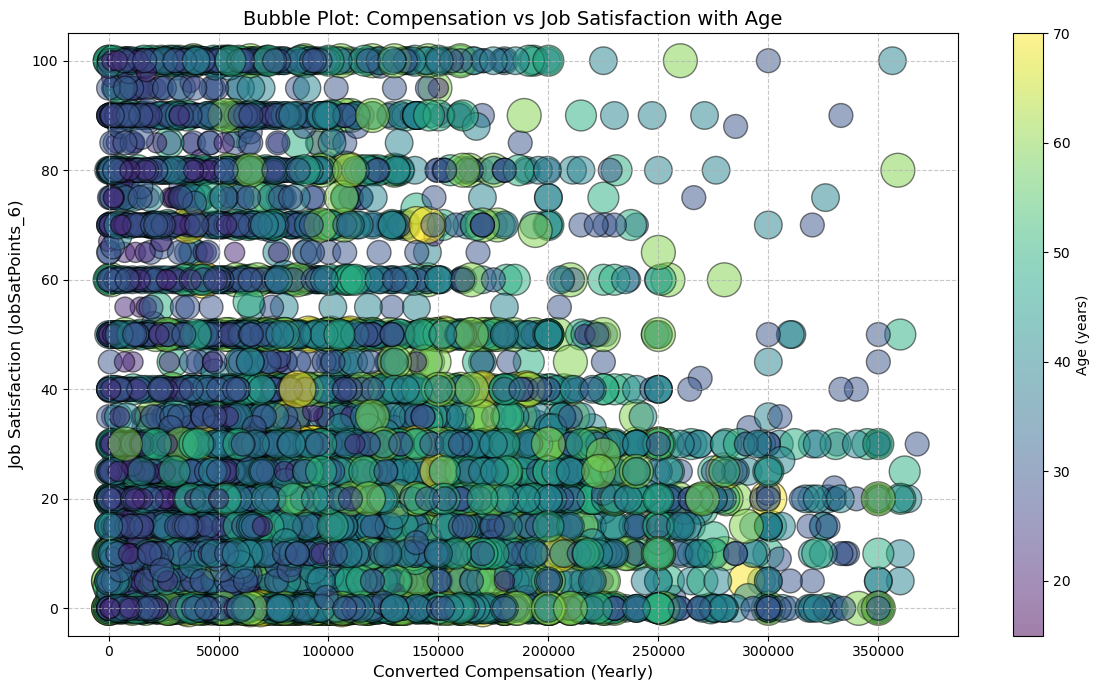

In [18]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# Select relevant columns and drop missing values
df_bubble = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric']].dropna()

# Optional: filter extreme compensation outliers
df_bubble = df_bubble[df_bubble['ConvertedCompYearly'] < df_bubble['ConvertedCompYearly'].quantile(0.99)]

# Define bubble size based on age (scaled for better visibility)
bubble_size = df_bubble['Age_numeric'] * 10  # adjust multiplier as needed

# Plot bubble chart
plt.figure(figsize=(12,7))
plt.scatter(
    df_bubble['ConvertedCompYearly'], 
    df_bubble['JobSatPoints_6'], 
    s=bubble_size, 
    alpha=0.5, 
    c=df_bubble['Age_numeric'],  # color by age as well
    cmap='viridis',
    edgecolor='k'
)
plt.colorbar(label='Age (years)')
plt.title('Bubble Plot: Compensation vs Job Satisfaction with Age', fontsize=14)
plt.xlabel('Converted Compensation (Yearly)', fontsize=12)
plt.ylabel('Job Satisfaction (JobSatPoints_6)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



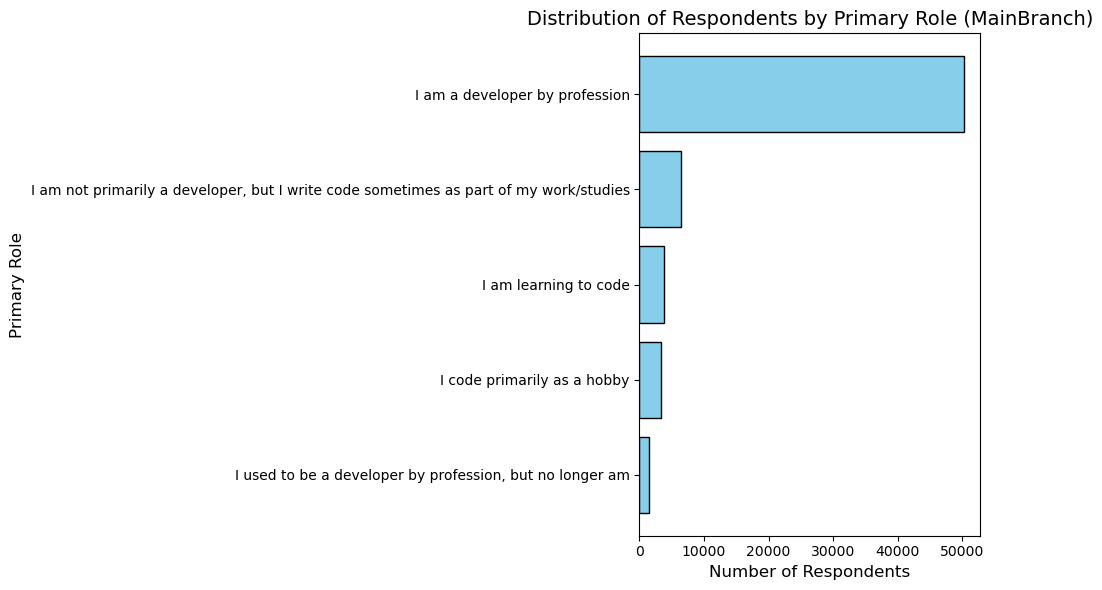

In [20]:
## Write your code here


# Count occurrences of each MainBranch
mainbranch_counts = df['MainBranch'].value_counts().sort_values(ascending=True)  # sort for horizontal bar

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(mainbranch_counts.index, mainbranch_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Respondents by Primary Role (MainBranch)', fontsize=14)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Primary Role', fontsize=12)
plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



LanguageWantToWorkWith
Python        25047
JavaScript    23774
SQL           22400
HTML/CSS      20721
TypeScript    20239
Name: count, dtype: int64

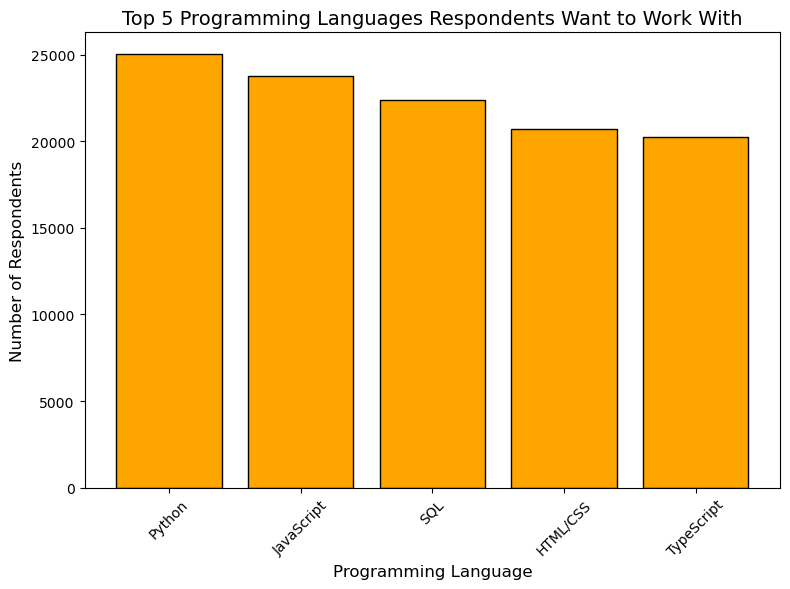

In [24]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# Select relevant column and drop missing values
df_lang = df[['LanguageWantToWorkWith']].dropna()

# Split multiple languages and explode into separate rows
df_lang = df_lang.assign(LanguageWantToWorkWith=df_lang['LanguageWantToWorkWith'].str.split(';')).explode('LanguageWantToWorkWith')

# Strip whitespace
df_lang['LanguageWantToWorkWith'] = df_lang['LanguageWantToWorkWith'].str.strip()

# Count occurrences of each language
lang_counts = df_lang['LanguageWantToWorkWith'].value_counts()

# Select top 5 languages
top5_langs = lang_counts.head(5)
display(top5_langs)

# Plot vertical bar chart
plt.figure(figsize=(8,6))
plt.bar(top5_langs.index, top5_langs.values, color='orange', edgecolor='black')
plt.title('Top 5 Programming Languages Respondents Want to Work With', fontsize=14)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


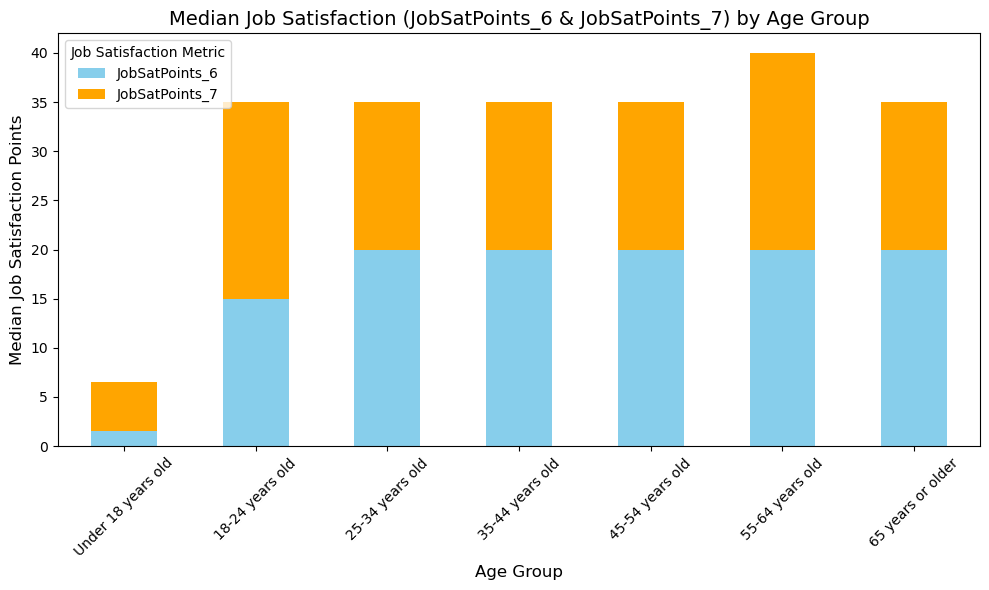

In [26]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# Select relevant columns and drop missing values
df_job = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Group by Age and calculate median of each job satisfaction metric
median_job = df_job.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Optional: sort age groups in natural order
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old', 
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]
median_job = median_job.reindex(age_order)

# Plot stacked bar chart
median_job.plot(kind='bar', stacked=True, figsize=(10,6), color=['skyblue', 'orange'])

plt.title('Median Job Satisfaction (JobSatPoints_6 & JobSatPoints_7) by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Job Satisfaction Points', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Job Satisfaction Metric')
plt.tight_layout()
plt.show()



##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



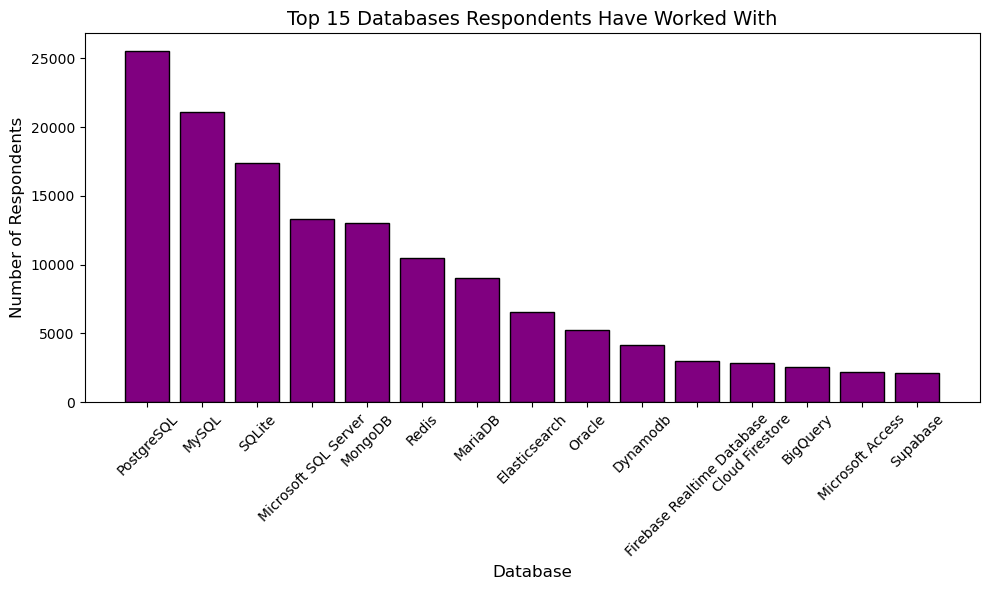

In [30]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# Select relevant column and drop missing values
df_db = df[['DatabaseHaveWorkedWith']].dropna()

# Split multiple databases and explode into separate rows
df_db = df_db.assign(DatabaseHaveWorkedWith=df_db['DatabaseHaveWorkedWith'].str.split(';')).explode('DatabaseHaveWorkedWith')

# Strip whitespace
df_db['DatabaseHaveWorkedWith'] = df_db['DatabaseHaveWorkedWith'].str.strip()

# Count occurrences of each database
db_counts = df_db['DatabaseHaveWorkedWith'].value_counts()

# Optional: select top 10 for readability
top10_dbs = db_counts.head(15)

# Plot vertical bar chart
plt.figure(figsize=(10,6))
plt.bar(top10_dbs.index, top10_dbs.values, color='purple', edgecolor='black')
plt.title('Top 15 Databases Respondents Have Worked With', fontsize=14)
plt.xlabel('Database', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



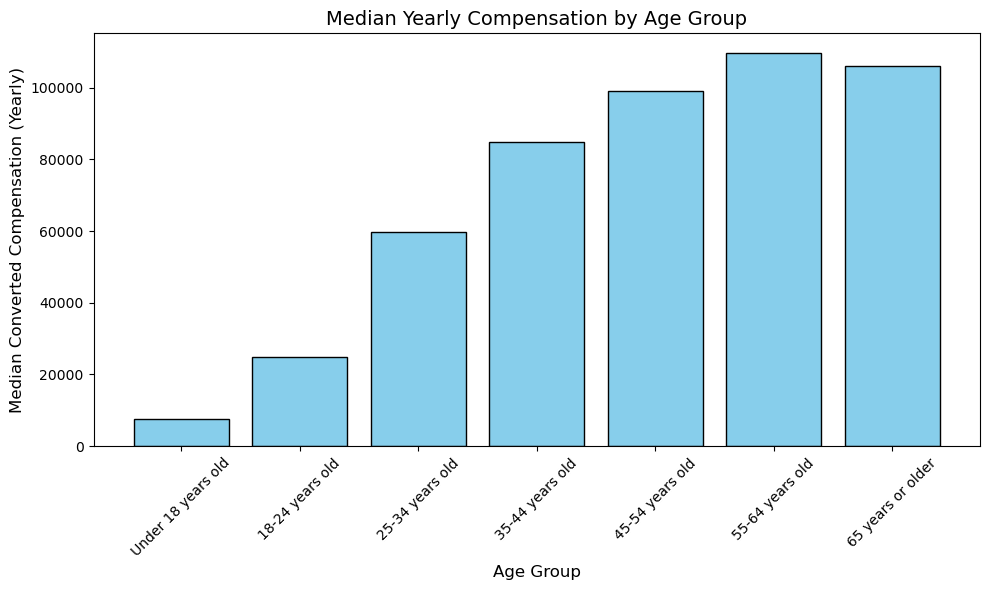

In [32]:
## Write your code here


# Select relevant columns and drop missing values
df_comp = df[['Age', 'ConvertedCompYearly']].dropna()

# Group by Age and calculate median compensation
median_comp = df_comp.groupby('Age')['ConvertedCompYearly'].median()

# Optional: sort age groups in natural order
age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]
median_comp = median_comp.reindex(age_order)

# Plot bar chart (grouped style if more than one metric)
plt.figure(figsize=(10,6))
plt.bar(median_comp.index, median_comp.values, color='skyblue', edgecolor='black')
plt.title('Median Yearly Compensation by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Converted Compensation (Yearly)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



Country
United States of America                                11095
Unknown                                                  6507
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
                                                        ...  
Niger                                                       1
Guinea                                                      1
Dominica                                                    1
Papua New Guinea                                            1
Solomon Islands                                             1
Name: count, Length: 186, dtype: int64

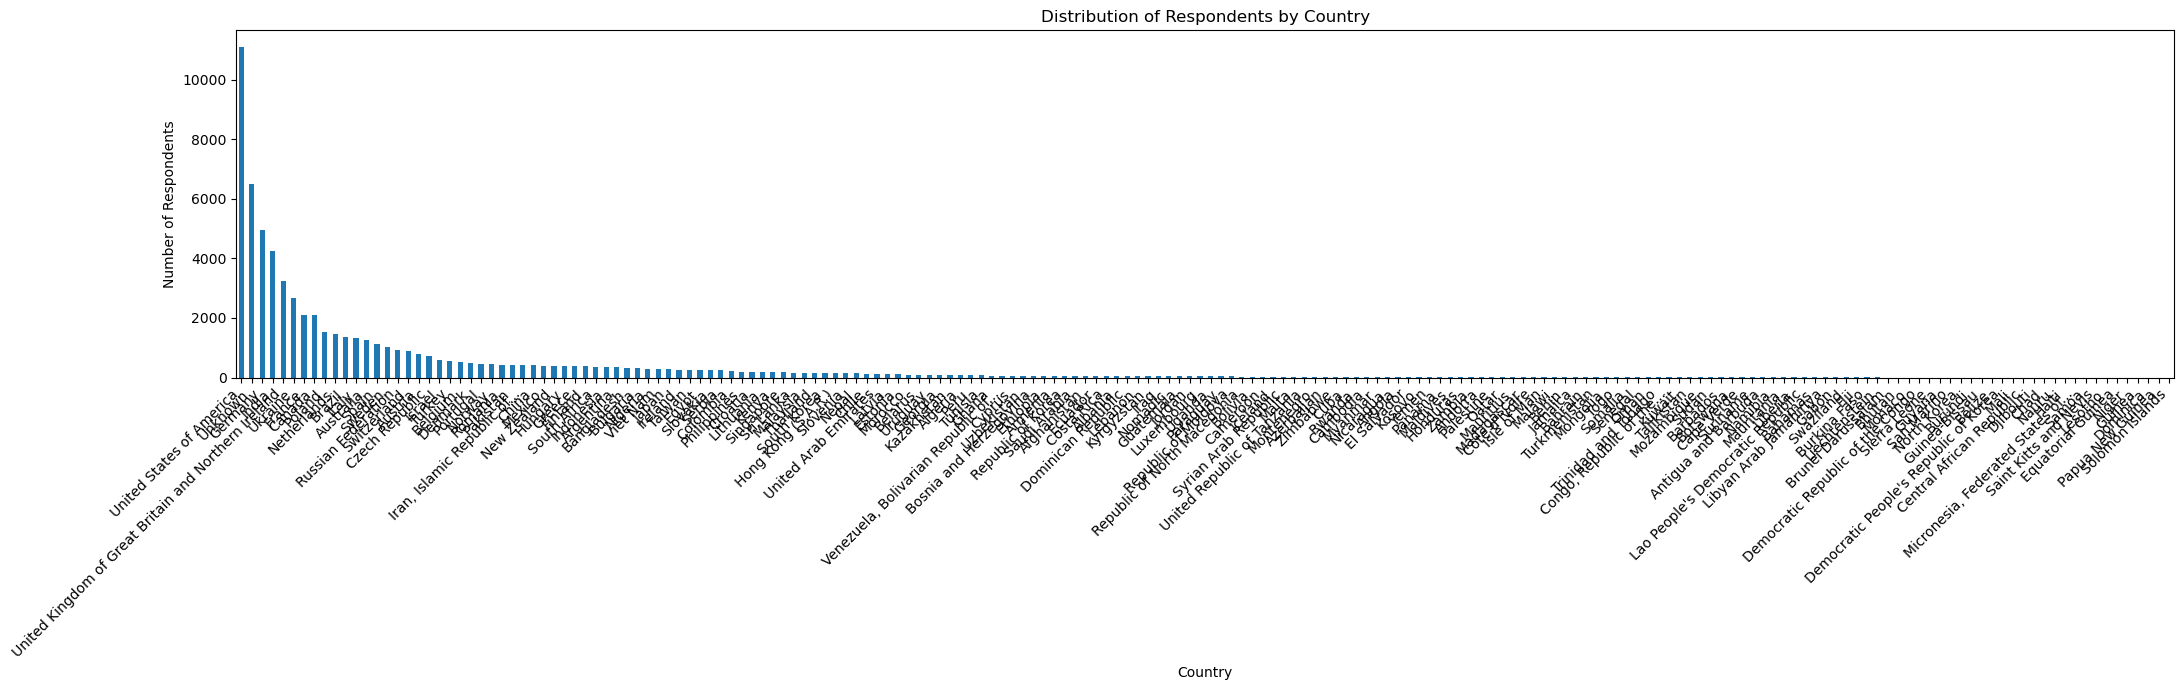

In [46]:
df_cleaned = df.dropna(subset=['Country']).copy()


country_counts = df_cleaned['Country'].value_counts()
display(country_counts)


plt.figure(figsize=(22, 7))
country_counts.plot(kind='bar')
plt.title('Distribution of Respondents by Country')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
